# Problem Statement

Retail businesses deal with customers having different purchasing patterns across product categories such as Fresh, Milk, Grocery, Frozen, Detergents, and Delicatessen.

The objective of this project is to use **Hierarchical Clustering** (Unsupervised Learning) to group customers based on similar product spending behaviour.

This helps retailers in:
- Customer segmentation
- Targeted marketing
- Inventory optimization
- Strategic decision-making

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Load wholesale customers dataset
df = pd.read_csv("C:/Users/MSK/Documents/DS_Project/Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## Dataset Description

- **Fresh**: Spending on fresh products
- **Milk**: Spending on milk products
- **Grocery**: Spending on grocery items
- **Frozen**: Spending on frozen food
- **Detergents_Paper**: Spending on cleaning products
- **Delicatessen**: Spending on ready-to-eat items
- **Channel**: Customer type
- **Region**: Geographic region

In [3]:
# Understand dataset structure and statistics
print(df.shape)
df.info()
df.describe().T

(440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [4]:
# Check and remove duplicate records
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Duplicates: 0


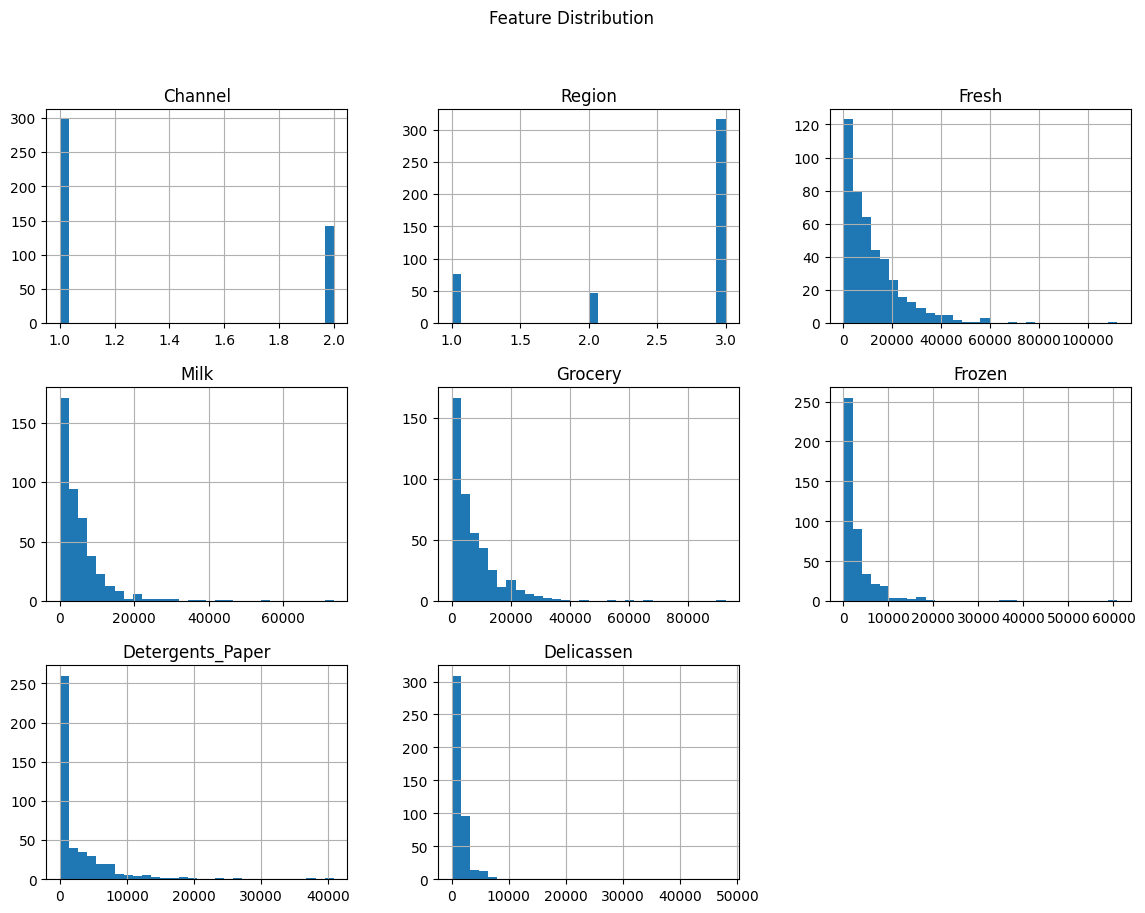

In [5]:
# Plot feature distributions
df.hist(figsize=(14,10), bins=30)
plt.suptitle("Feature Distribution")
plt.show()

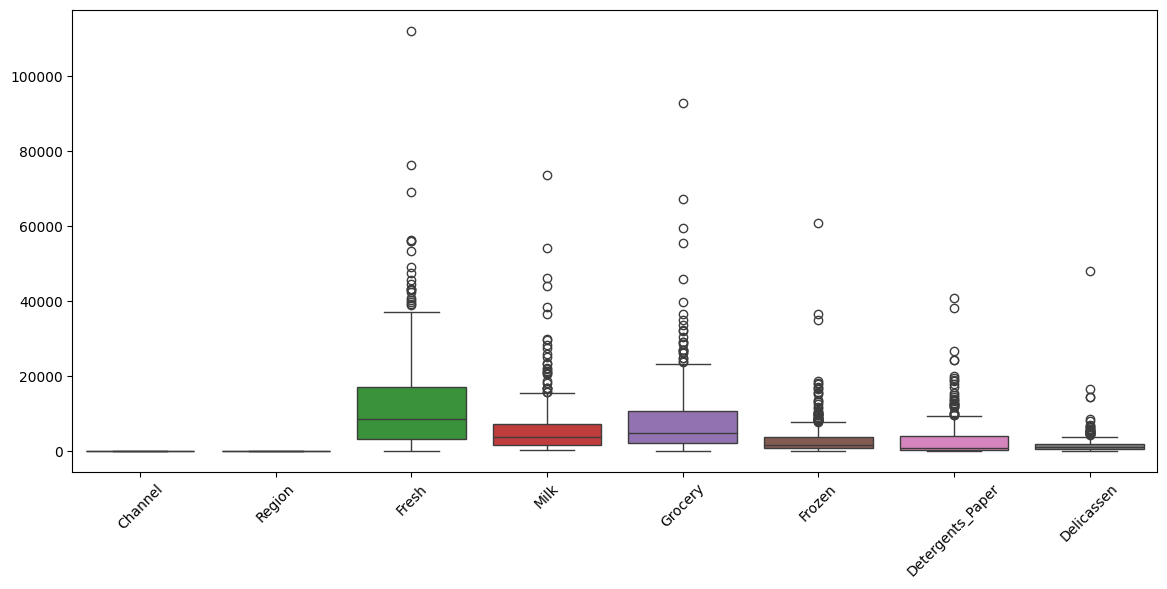

In [6]:
# Detect outliers using boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [7]:
# Remove categorical columns not required for clustering
df_features = df.drop(['Channel','Region'], axis=1)

In [8]:
# Reduce skewness in data
df_log = np.log1p(df_features)

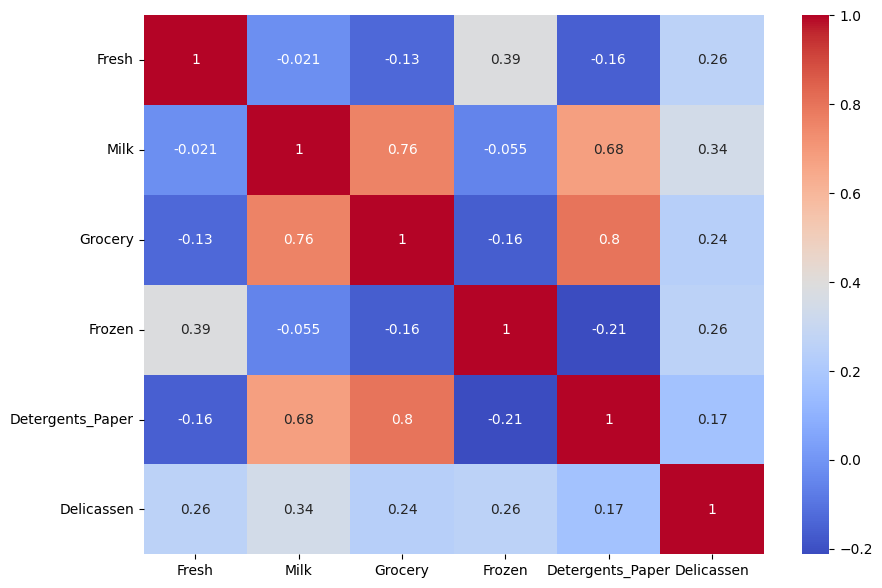

In [9]:
# Visualize correlation between product spending
plt.figure(figsize=(10,7))
sns.heatmap(df_log.corr(), annot=True, cmap='coolwarm')
plt.show()

In [10]:
# Standardize dataset before clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_log)
scaled_df = pd.DataFrame(scaled_data, columns=df_log.columns)

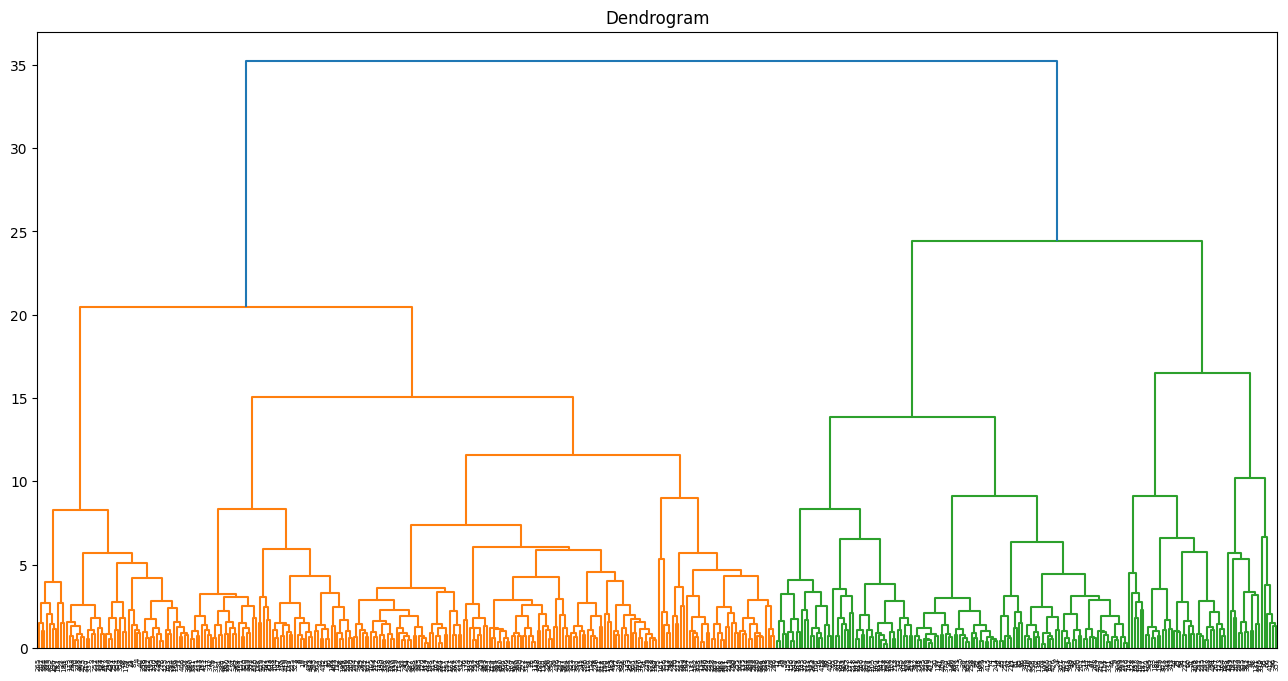

In [11]:
# Plot dendrogram to find optimal clusters
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(16,8))
sch.dendrogram(sch.linkage(scaled_df, method='ward'))
plt.title("Dendrogram")
plt.show()

In [12]:
# Apply Agglomerative Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = model.fit_predict(scaled_df)
df['Cluster'] = clusters

In [13]:
# Evaluate clustering performance
from sklearn.metrics import silhouette_score
score = silhouette_score(scaled_df, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.2020795686473931


In [14]:
# Check number of customers per cluster
df['Cluster'].value_counts()

Cluster
1    208
2    125
3     54
0     53
Name: count, dtype: int64

In [15]:
# Analyze average spending pattern in each cluster
cluster_profile = df.groupby('Cluster').mean()
cluster_profile

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.490566,2.641509,3913.962264,5222.981132,8657.924528,1198.415094,3474.113208,190.490566
1,1.028846,2.519231,12025.649038,2279.826923,2880.620192,2493.173077,538.802885,882.221154
2,1.840000,2.576000,9107.784000,11083.008000,16616.928000,1527.336000,7377.008000,2032.208000
3,1.092593,2.462963,26534.870370,7665.907407,6729.759259,10715.500000,917.259259,4135.537037


## Cluster Naming

- **Cluster 0**: Premium Bulk Buyers (High Grocery & Milk)
- **Cluster 1**: Fresh Product Buyers (Restaurants / Hotels)
- **Cluster 2**: Balanced Buyers (Medium spending across categories)
- **Cluster 3**: Low Volume Buyers (Small retailers / Occasional buyers)

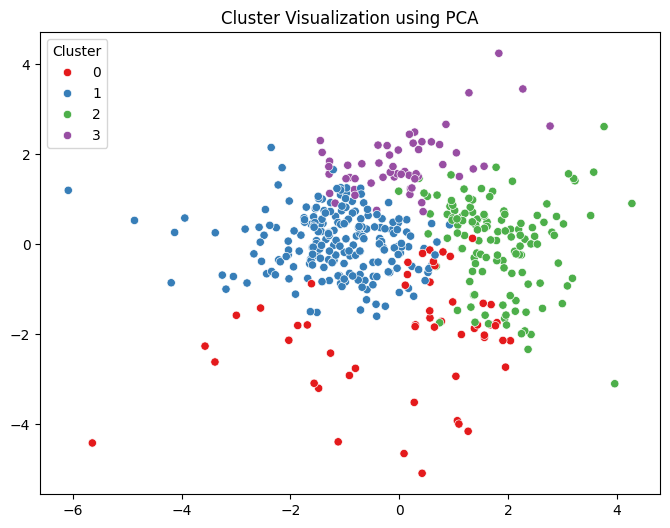

In [16]:
# Visualize clusters in 2D using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df['Cluster'], palette='Set1')
plt.title("Cluster Visualization using PCA")
plt.show()

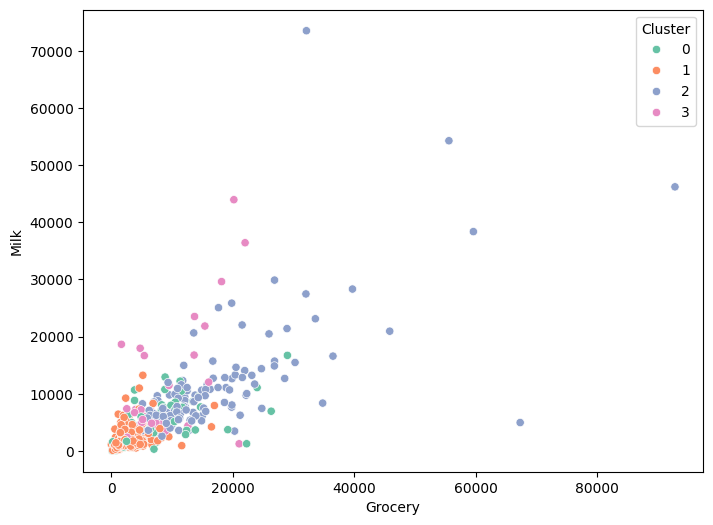

In [17]:
# Visualize spending behaviour between Grocery and Milk
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Grocery'], y=df['Milk'], hue=df['Cluster'], palette='Set2')
plt.show()

## Final Business Insights

- Hierarchical Clustering successfully segmented retail customers based on their purchasing patterns.
- Some clusters represent bulk grocery and milk buyers, such as supermarkets, while others indicate fresh product buyers like restaurants and hotels.
- Balanced and low-spending clusters represent small retailers or occasional buyers.
  
These insights help businesses in:
- Designing targeted promotions
- Optimizing inventory levels
- Improving store layout planning
- Increasing profitability through better customer understanding